# Gaussian Process tool

In [1]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from GaussianProcess.GPengine import GPCalculator

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
possible_derivatives = ['f','int','d1','d2']

# Settings

In [3]:
N_recon = 10
xmin_recon = 0.
xmax_recon = 2.
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

x_label = r'$x$'
y_label = r'$f(x)$'

#Om = 0.32
#H0 = 67.

#theory_model = {'y': lambda x: H0*np.sqrt(Om*(1+x)**3+(1-Om))}

fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1}

from parametric_approach.polynomial import PolynomialFit
theory = PolynomialFit(None,None,order=3)
theory_model = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

# Create or load data

Here we simulate $H(z)$ data **(To be done better)**

In [4]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 10

In [5]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})
#dataset = pd.DataFrame({'x': np.linspace(xmin,xmax,Ndata)})

thvals = theory_model(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

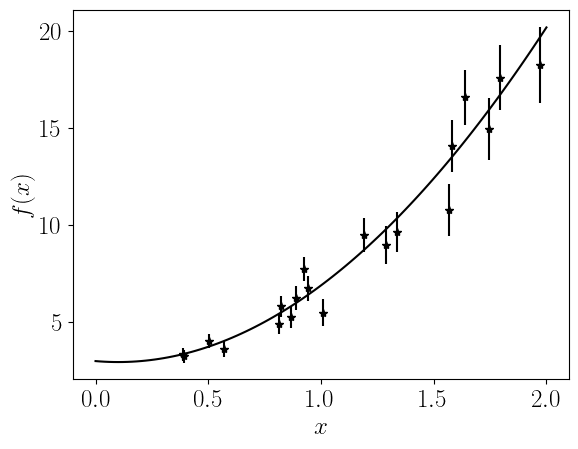

In [6]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
if theory_model != None:
    plt.plot(xplot,theory_model(xplot)['f'],color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# Gaussian process

blablabla

In [7]:
available_kernels = ['RBF','MATERN3/2','MATERN5/2']

## Simple run

The GPCalculator class can be initialized by giving as input the dataset and the covariance matrix 
for the function to reconstruct, together with the selected kernel.

After that, one can obtain a reconstruction straightforwardly by specifying the values of the kernel's hyperparameters (and nsteps **CHECK**)

The output of the reconstruction method is the mean values of the function at given points and the covariance of the predicted values.

This is not done only for the function itself, but also for its derivatives (up to the second when possible) and its integral.
For the latter, we need to specify the starting point of the integral and the number of steps taken.

**WARNING: SOMETHING WEIRD HAPPENING WITH THE SECOND DERIVATIVES IN MATERN KERNELS... REMOVING THEM FOR NOW!**

In [8]:
l     = 1
sigma = 1
integral_start = 0.
n_int_steps = 50

In [9]:
dfs = []
for kernel in available_kernels:
    tini = time()
    gp = GPCalculator(dataset,covmat,kernel_type=kernel)
    mu,cov = gp.predict_at_params(x_recon,l,sigma,integral_start,n_int_steps)
    
    #Unpacking results in human format (this is done in the code with the full approach)
    results = gp._unpack(mu,cov,x_recon)
    mean_df = pd.DataFrame({'x':x_recon}|results['means'])
    
    mean_df['Kernel'] = kernel 
        
    cols = []
    for func in results['means'].keys():
        cols = cols+['{}_{}'.format(func,ind) for ind in range(len(x_recon))]
    covmat_df = pd.DataFrame(cov,columns=cols,index=cols)
    
    for func in possible_derivatives:
        cov = covmat_df[[func+'_{}'.format(ind) for ind in range(N_recon)]]
        cov = cov.drop(index=[ind for ind in cov.index if ind not in [func+'_{}'.format(ind) for ind in range(N_recon)]])
        mean_df[func+'_err'] = np.sqrt(np.diag(cov))

    #TEMPORARY! (I hope)
    if kernel != 'RBF':
        mean_df['d2']     = np.nan
        mean_df['d2_err'] = np.nan 

    print(kernel+' done in {:.2f} s'.format(time()-tini))

    dfs.append(mean_df)

simple_GP = pd.concat(dfs,ignore_index=True)

RBF done in 18.53 s
MATERN3/2 done in 30.82 s
MATERN5/2 done in 21.25 s


/tmp/ipykernel_10914/4049607375.py:21: RuntimeWarning: invalid value encountered in sqrt
  mean_df[func+'_err'] = np.sqrt(np.diag(cov))


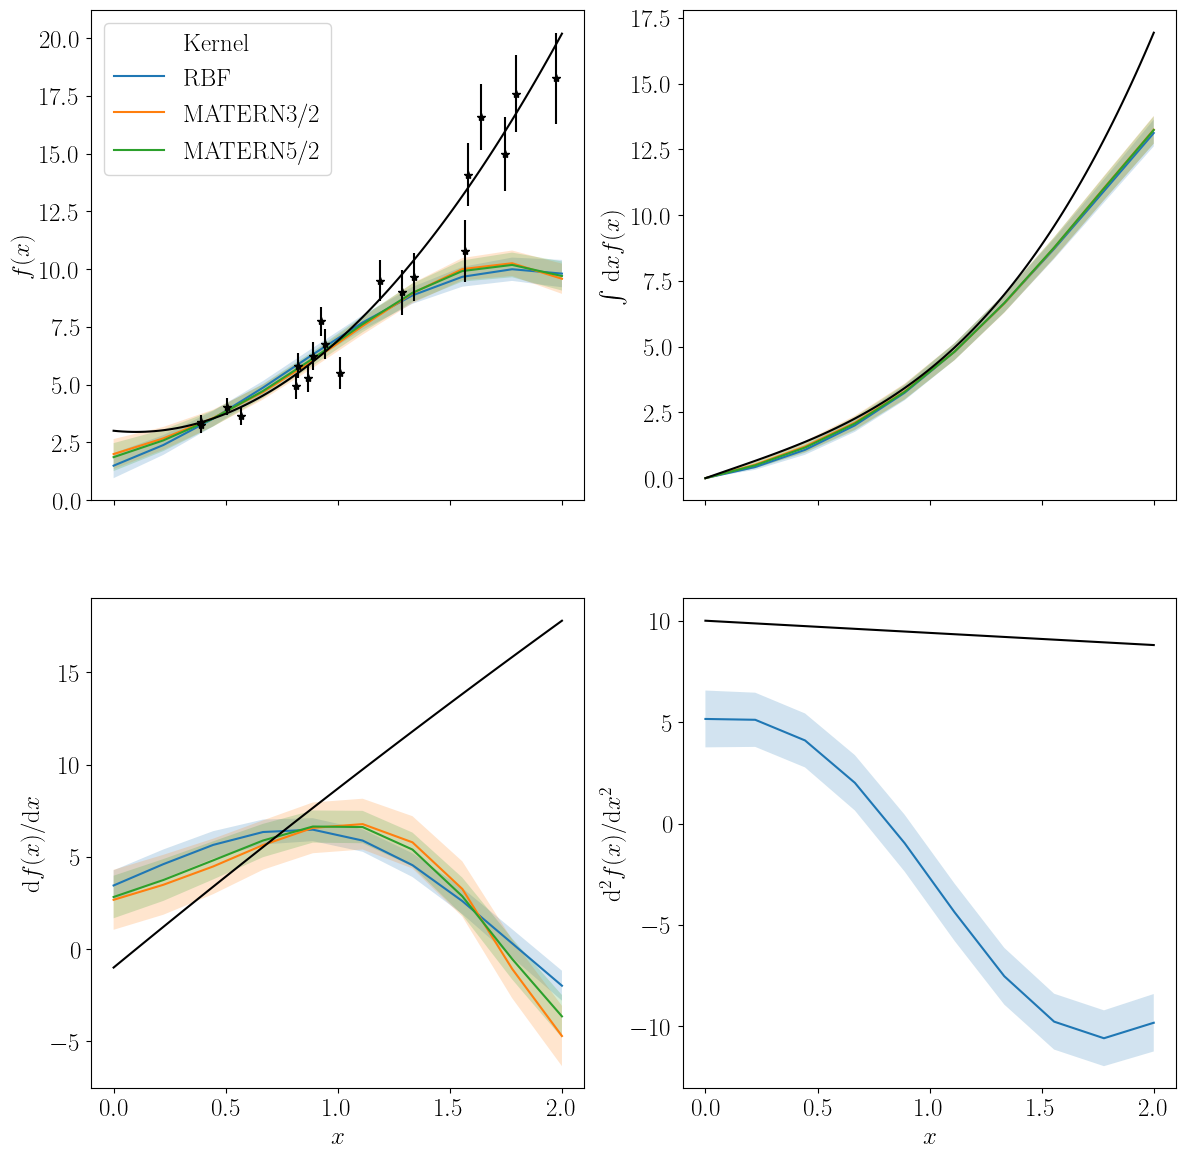

In [10]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for kernel in simple_GP['Kernel'].unique():
        df = simple_GP[simple_GP['Kernel']==kernel]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(simple_GP,x='x',y=deriv,hue='Kernel',ax=axes[i,j])
    else:
        sb.lineplot(simple_GP,x='x',y=deriv,hue='Kernel',ax=axes[i,j],legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

## Choosing hyper-parameters

The choice of hyper-parameters can be handled by the GPCalculator class, which offers the possibility
to switch between an optimization approach and a marginalization approach.

For this example we fix the kernel to RBF

In [11]:
reconstructions = {}

In [12]:
gp = GPCalculator(dataset,covmat,kernel_type='RBF')

### Optimized

**Explain optimization here**

In [13]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='MAP')

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Optimized'] = {'Functions': means}

best_fit = info['Best-fit']

Optimizing (MAP)...
GP done in 10.10 s


### Marginalized

**Explain marginalization here**

In [ ]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=10000,thinning=70,burn_in=0.3)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Marginalized'] = {'Functions': means}

sample = info['sample']

Sampling (MCMC)...
Removed 0.3 as burn in


### Visualize hyper-parameters

In [ ]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot(sample,['l','sigma'],legend_loc='upper right',
                filled=False,contour_lws=2,
                markers=best_fit
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Comparison

In [ ]:
dfs = []

for name,recon in reconstructions.items():
    df = pd.DataFrame(recon['Functions'])
    df['Method'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

In [ ]:
results

In [ ]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in results['Method'].unique():
        df = results[results['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j])
    else:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j],legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)